# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Nama Dataset: dair-ai/emotion\
Sumber: Kaggle/Hugging Face\
Task: Multiclass text classification \
Dataset ini berisi teks pendek berbahasa Inggris yang dilabeli ke dalam 6 emosi: sadness, joy, love, anger, fear, dan surprise.
https://github.com/dair-ai/emotion_dataset


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import re
import json
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
sns.set(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

[nltk_data] Downloading package stopwords to /Users/arya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
import pandas as pd

raw_path = "../emotion_raw/merged_training.pkl"
df = pd.read_pickle(raw_path)

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (416809, 2)


,text,emotions
27383,i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here,sadness
110083,im alone i feel awful,sadness
140764,ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals,joy
100071,i was feeling a little low few days back,sadness
2837,i beleive that i am much more sensitive to other peoples feelings and tend to be more compassionate,love


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### Insight EDA
Berdasarkan EDA, dataset memiliki enam kelas emosi utama yaitu sadness, joy, love, anger, fear, dan surprise. Selanjutnya dilakukan preprocessing teks agar data menjadi lebih bersih, seragam, dan siap digunakan pada proses pelatihan model deep learning.

,text,emotions,char_length,word_count
27383,i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here,sadness,112,26
110083,im alone i feel awful,sadness,21,5
140764,ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals,joy,152,27
100071,i was feeling a little low few days back,sadness,40,9
2837,i beleive that i am much more sensitive to other peoples feelings and tend to be more compassionate,love,99,18


=== Informasi Dasar ===
<class 'pandas.DataFrame'>
Index: 416809 entries, 27383 to 64703
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         416809 non-null  object
 1   emotions     416809 non-null  object
 2   char_length  416809 non-null  int64 
 3   word_count   416809 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 15.9+ MB

Ukuran dataset: (416809, 4)
Jumlah data duplikat: 686
Jumlah missing values:
text           0
emotions       0
char_length    0
word_count     0
dtype: int64

=== Distribusi Label Emosi ===
emotions
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64


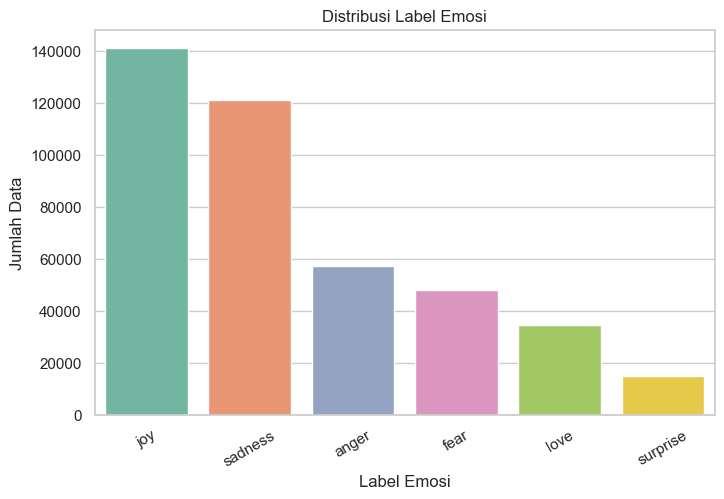


=== Statistik Panjang Karakter dan Kata ===


,char_length,word_count
count,416809.000000,416809.000000
mean,97.028397,19.211015
std,56.198232,11.051049
min,2.000000,1.000000
25%,54.000000,11.000000
50%,86.000000,17.000000
75%,128.000000,25.000000
max,830.000000,178.000000


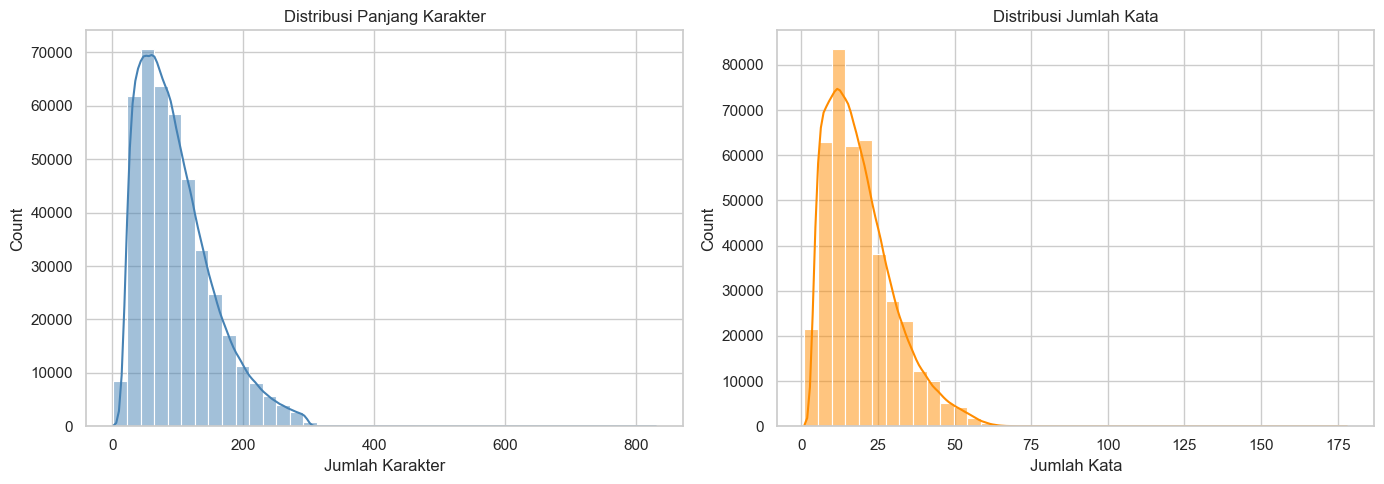

=== Contoh Teks per Emosi ===
[SADNESS]: i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here
[JOY]: ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals
[LOVE]: i beleive that i am much more sensitive to other peoples feelings and tend to be more compassionate
[ANGER]: i feel so enraged but helpless at the same time
[FEAR]: i feel weird knowing mine died when i wasn t around
[SURPRISE]: i pretty much waddled out of the hospital feeling weird lightheaded but ok


In [19]:
display(df.head())

# Dataset Info
print("=== Informasi Dasar ===")
df.info()
print(f"\nUkuran dataset: {df.shape}")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")
print(f"Jumlah missing values:\n{df.isnull().sum()}")

# Label Distribution
print("\n=== Distribusi Label Emosi ===")
label_counts = df["emotions"].value_counts()
print(label_counts)

# Visualisasi distribusi label emosi
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="emotions",
    order=label_counts.index,
    palette="Set2"
)
plt.title("Distribusi Label Emosi")
plt.xlabel("Label Emosi")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.show()

# Menambah kolom baru (panjang karakter & kata) untuk analisis teks
df["char_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("\n=== Statistik Panjang Karakter dan Kata ===")
display(df[["char_length", "word_count"]].describe())

# Visualisasi grafik distribusi teks
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df["char_length"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah Karakter")

sns.histplot(df["word_count"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribusi Jumlah Kata")
axes[1].set_xlabel("Jumlah Kata")

plt.tight_layout()
plt.show()

# Data example
print("=== Contoh Teks per Emosi ===")
for label in df["emotions"].unique():
    sample_text = df[df["emotions"] == label]["text"].iloc[0]
    print(f"[{label.upper()}]: {sample_text}")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Shape setelah menghapus duplikasi: (403921, 5)


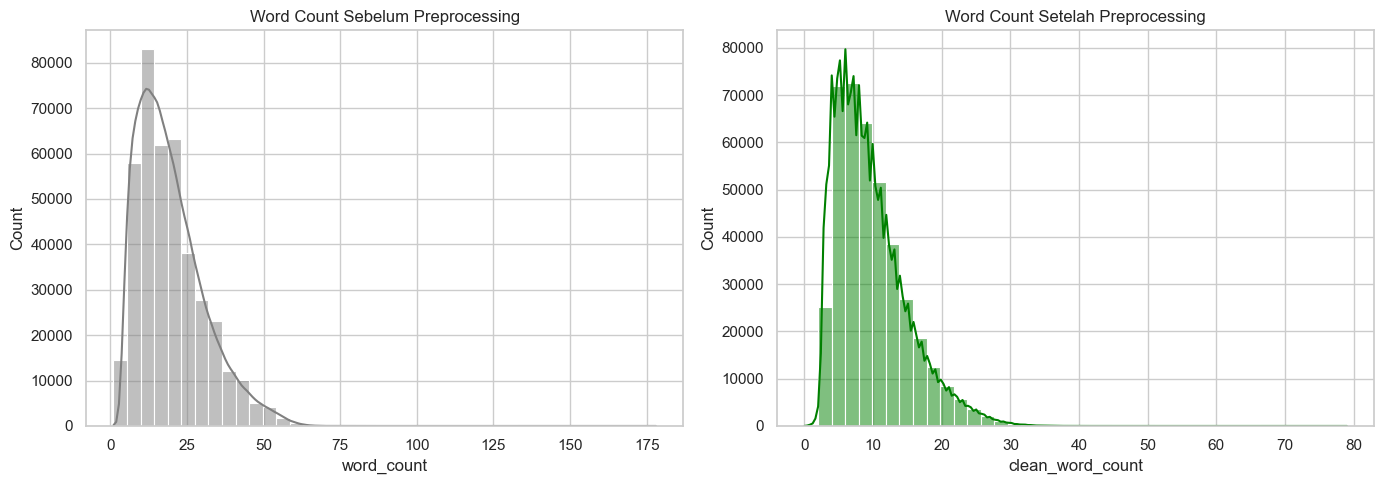

,text_clean,emotions
0,feel awful job get position succeed happen,sadness
1,im alone feel awful,sadness
2,ive probably mentioned really feel proud actually keeping new years resolution monthly weekly goals,joy
3,feeling little low days back,sadness
4,beleive much sensitive peoples feelings tend compassionate,love


In [23]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+|https\\S+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"#\\w+", "", text)
    text = re.sub(r"[^a-zA-Z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df_preprocessed = df.copy()

df_preprocessed["text_clean"] = df_preprocessed["text"].apply(clean_text)
df_preprocessed["text_clean"] = df_preprocessed["text_clean"].apply(remove_stopwords)

df_preprocessed[["text", "text_clean", "emotions"]].head(10)

df_preprocessed.isnull().sum()

df_preprocessed.duplicated(subset=["text_clean", "emotions"]).sum()

df_preprocessed = df_preprocessed.drop_duplicates(subset=["text_clean", "emotions"]).reset_index(drop=True)
print("Shape setelah menghapus duplikasi:", df_preprocessed.shape)

df_preprocessed["clean_word_count"] = df_preprocessed["text_clean"].apply(lambda x: len(x.split()))

df_preprocessed[["word_count", "clean_word_count"]].describe()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_preprocessed["word_count"], bins=40, kde=True, ax=axes[0], color="gray")
axes[0].set_title("Word Count Sebelum Preprocessing")

sns.histplot(df_preprocessed["clean_word_count"], bins=40, kde=True, ax=axes[1], color="green")
axes[1].set_title("Word Count Setelah Preprocessing")

plt.tight_layout()
plt.show()

final_df = df_preprocessed[["text_clean", "emotions"]].copy()
final_df.head()

In [24]:
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    stratify=final_df["emotions"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["emotions"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Distribusi Train")
print(train_df["emotions"].value_counts(normalize=True))

print("\nDistribusi Validation")
print(val_df["emotions"].value_counts(normalize=True))

print("\nDistribusi Test")
print(test_df["emotions"].value_counts(normalize=True))


import os

os.makedirs("emotions_preprocessing", exist_ok=True)

train_df.to_csv("emotions_preprocessing/train_preprocessed.csv", index=False)
val_df.to_csv("emotions_preprocessing/val_preprocessed.csv", index=False)
test_df.to_csv("emotions_preprocessing/test_preprocessed.csv", index=False)

print("Semua file preprocessing berhasil disimpan.")

train_df.head()

print("Jumlah data akhir:")
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

print("\nKolom final:")
print(train_df.columns.tolist())

Train shape: (290822, 2)
Validation shape: (32314, 2)
Test shape: (80785, 2)
Distribusi Train
emotions
joy         0.338984
sadness     0.289198
anger       0.137290
fear        0.114510
love        0.083773
surprise    0.036246
Name: proportion, dtype: float64

Distribusi Validation
emotions
joy         0.338986
sadness     0.289194
anger       0.137309
fear        0.114501
love        0.083772
surprise    0.036238
Name: proportion, dtype: float64

Distribusi Test
emotions
joy         0.338986
sadness     0.289187
anger       0.137290
fear        0.114514
love        0.083778
surprise    0.036244
Name: proportion, dtype: float64
Semua file preprocessing berhasil disimpan.
Jumlah data akhir:
Train      : 290822
Validation : 32314
Test       : 80785

Kolom final:
['text_clean', 'emotions']
